In [25]:
!pip install datasets transformers
!pip install fvcore
!pip install -U zetascale

  Using cached argparse-1.4.0-py2.py3-none-any.whl.metadata (2.8 kB)
Using cached argparse-1.4.0-py2.py3-none-any.whl (23 kB)


In [26]:
!apt-get install git-lfs
!git lfs install
!GIT_LFS_SKIP_SMUDGE=1 git clone https://huggingface.co/datasets/allenai/c4
%cd c4
!git lfs pull --include "en/c4-train.00000-of-01024.json.gz"

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
git-lfs is already the newest version (3.0.2-1ubuntu0.2).
0 upgraded, 0 newly installed, 0 to remove and 49 not upgraded.
Updated git hooks.
Git LFS initialized.
Cloning into 'c4'...
remote: Enumerating objects: 87108, done.
remote: Total 87108 (delta 0), reused 0 (delta 0), pack-reused 87108 (from 1)
Receiving objects: 100% (87108/87108), 12.30 MiB | 9.01 MiB/s, done.
Resolving deltas: 100% (30/30), done.
Updating files: 100% (69221/69221), done.
/content/c4/c4/c4/c4/c4/c4/c4


In [27]:
from datasets import load_dataset

from transformers import T5TokenizerFast, T5Tokenizer

import gzip
import json

def load_json_gz(filepath):
    with gzip.open(filepath, 'rb') as f:
        for line in f:
            yield json.loads(line)

# Load the small subset you downloaded
dataset_path = 'en/c4-train.00000-of-01024.json.gz'
data = list(load_json_gz(dataset_path))

# Preview a few examples
print(data[:2])

# Load the fast version of the T5 tokenizer
#tokenizer = T5TokenizerFast.from_pretrained("t5-base")
tokenizer = T5Tokenizer.from_pretrained('t5-small', use_fast=True)
# Load the C4 dataset
tokenized_data = [tokenizer.encode(d['text'], return_tensors='pt') for d in data[:100]]

#tokenized_data.set_format(type="torch", columns=["input_ids"])

[{'text': 'Beginners BBQ Class Taking Place in Missoula!\nDo you want to get better at making delicious BBQ? You will have the opportunity, put this on your calendar now. Thursday, September 22nd join World Class BBQ Champion, Tony Balay from Lonestar Smoke Rangers. He will be teaching a beginner level class for everyone who wants to get better with their culinary skills.\nHe will teach you everything you need to know to compete in a KCBS BBQ competition, including techniques, recipes, timelines, meat selection and trimming, plus smoker and fire information.\nThe cost to be in the class is $35 per person, and for spectators it is free. Included in the cost will be either a t-shirt or apron and you will be tasting samples of each meat that is prepared.', 'timestamp': '2019-04-25T12:57:54Z', 'url': 'https://klyq.com/beginners-bbq-class-taking-place-in-missoula/'}, {'text': 'Discussion in \'Mac OS X Lion (10.7)\' started by axboi87, Jan 20, 2012.\nI\'ve got a 500gb internal drive and a 24

Energy for expert  0 48.69
Flops for expert layer  0 26.080182272
Energy for expert  1 45.3
Flops for expert layer  1 26.080182272
Energy for expert  2 53.38
Flops for expert layer  2 26.080182272
Energy for expert  3 29.71
Flops for expert layer  3 26.080182272
Energy for expert  4 52.03
Flops for expert layer  4 26.080182272
Energy for expert  5 30.72
Flops for expert layer  5 26.080182272


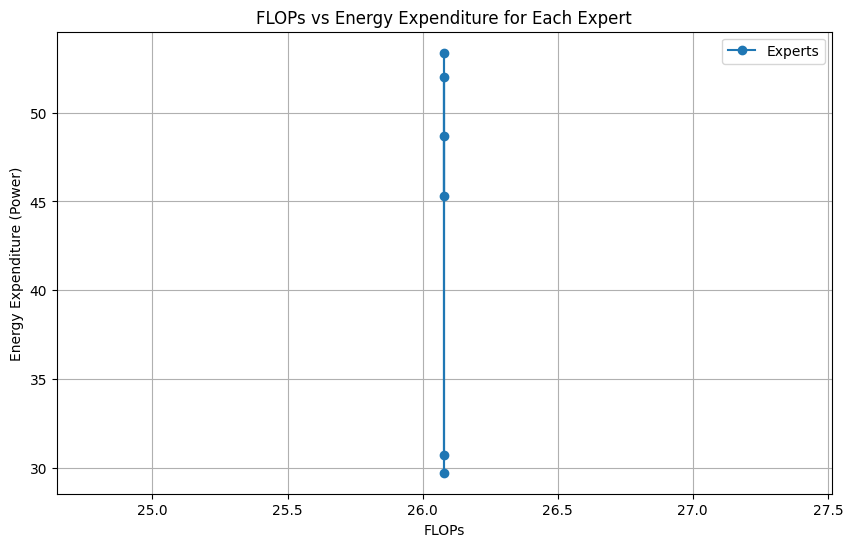

Computing calibration metrics...
Expected Calibration Error: 0.006


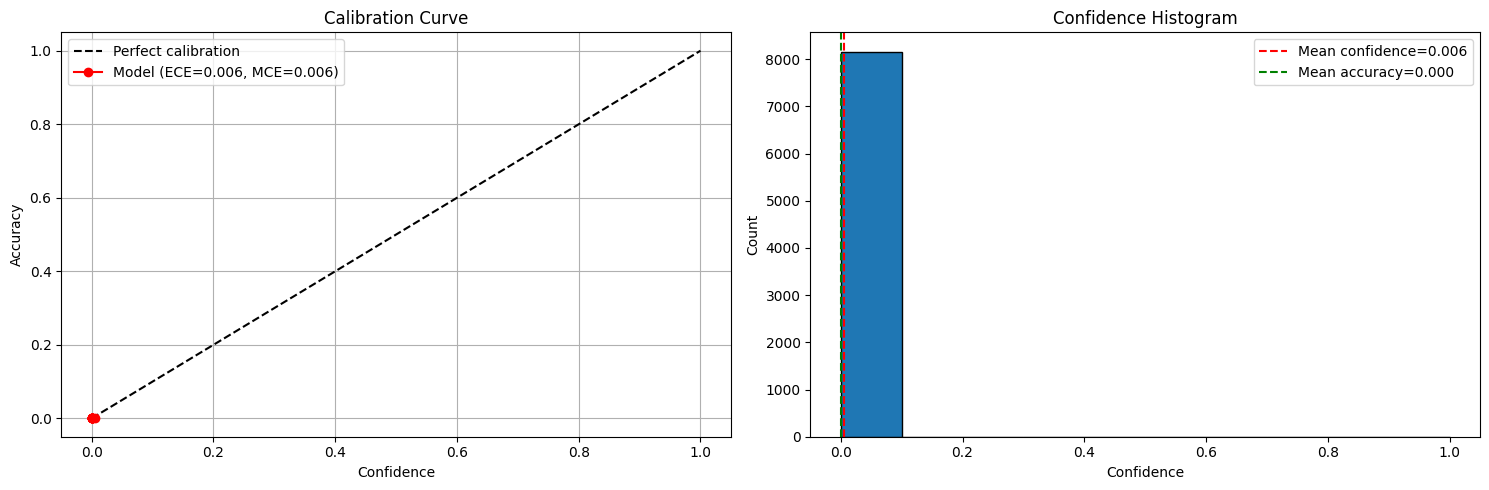

Energy for expert  0 81.84
Flops for expert layer  0 26.080182272
Energy for expert  1 68.93
Flops for expert layer  1 26.080182272
Energy for expert  2 66.61
Flops for expert layer  2 26.080182272
Energy for expert  3 41.67
Flops for expert layer  3 26.080182272
Energy for expert  4 36.86
Flops for expert layer  4 26.080182272
Energy for expert  5 38.33
Flops for expert layer  5 26.080182272


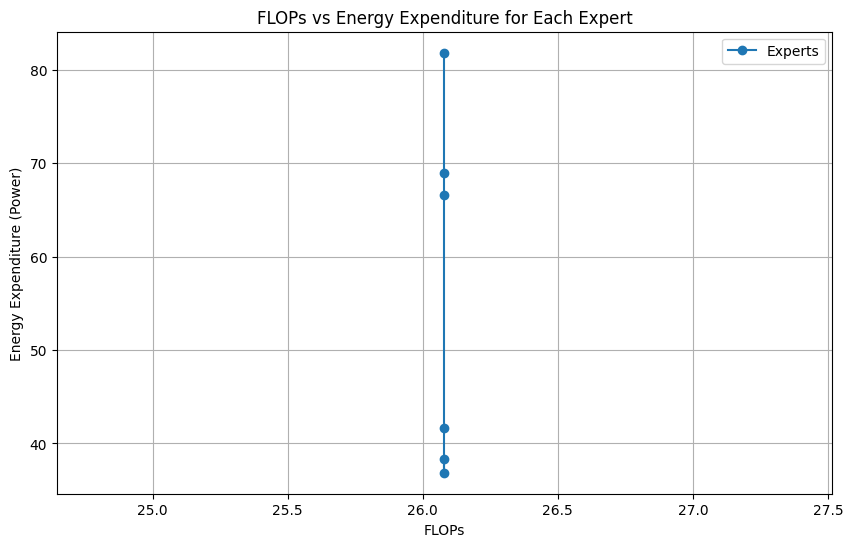

Energy for expert  0 76.81
Flops for expert layer  0 26.080182272
Energy for expert  1 39.11
Flops for expert layer  1 26.080182272
Energy for expert  2 77.2
Flops for expert layer  2 26.080182272
Energy for expert  3 51.64
Flops for expert layer  3 26.080182272
Energy for expert  4 30.3
Flops for expert layer  4 26.080182272
Energy for expert  5 55.77
Flops for expert layer  5 26.080182272


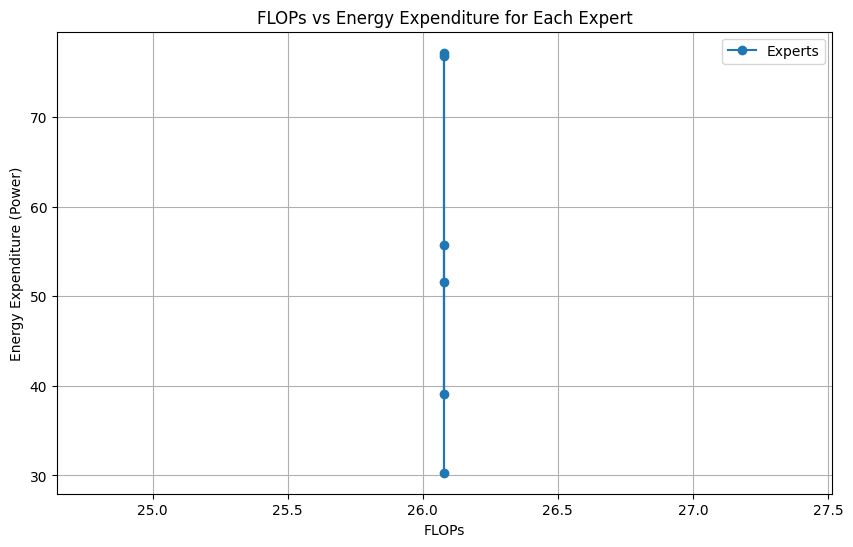

Epoch 1/5, Loss: 20.339580535888672, Top-k Accuracy (k=5): 0.2236519607843137


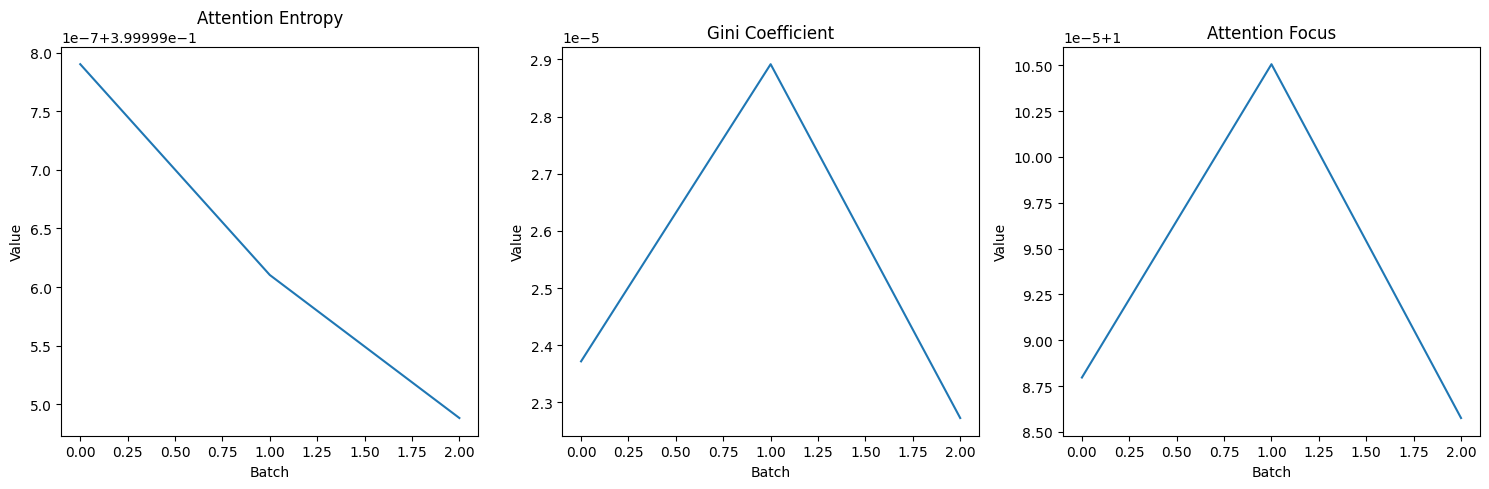


Computing calibration metrics...
Expected Calibration Error: 0.483


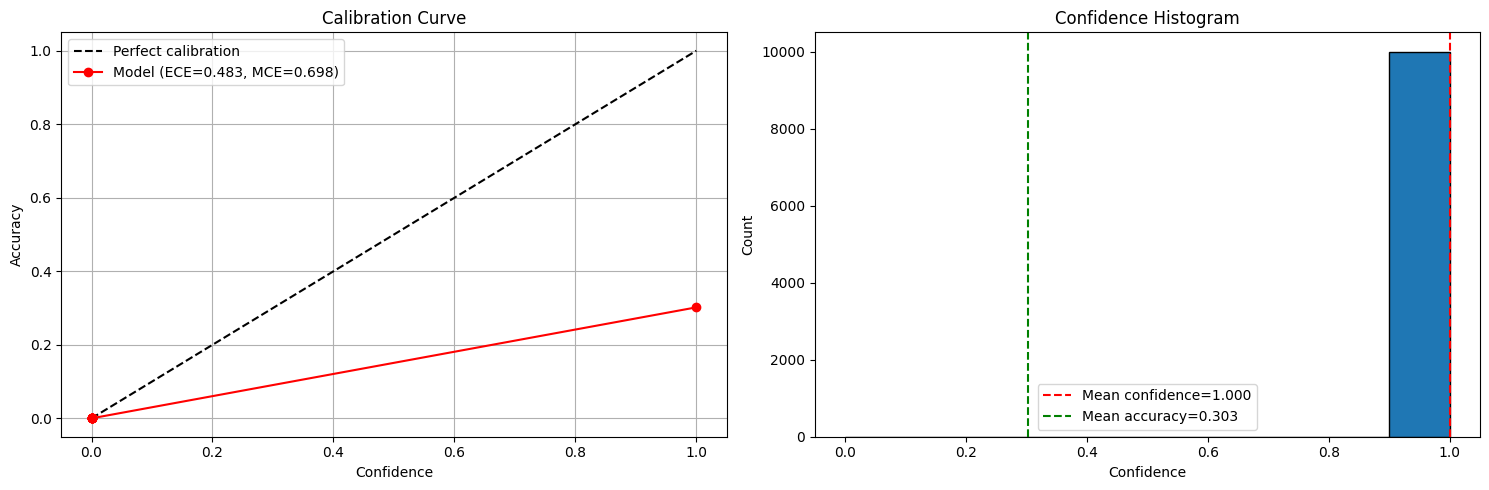

Energy for expert  0 32.675
Flops for expert layer  0 26.080182272
Energy for expert  1 30.02
Flops for expert layer  1 26.080182272
Energy for expert  2 54.66
Flops for expert layer  2 26.080182272
Energy for expert  3 39.82
Flops for expert layer  3 26.080182272
Energy for expert  4 29.82
Flops for expert layer  4 26.080182272
Energy for expert  5 54.43
Flops for expert layer  5 26.080182272


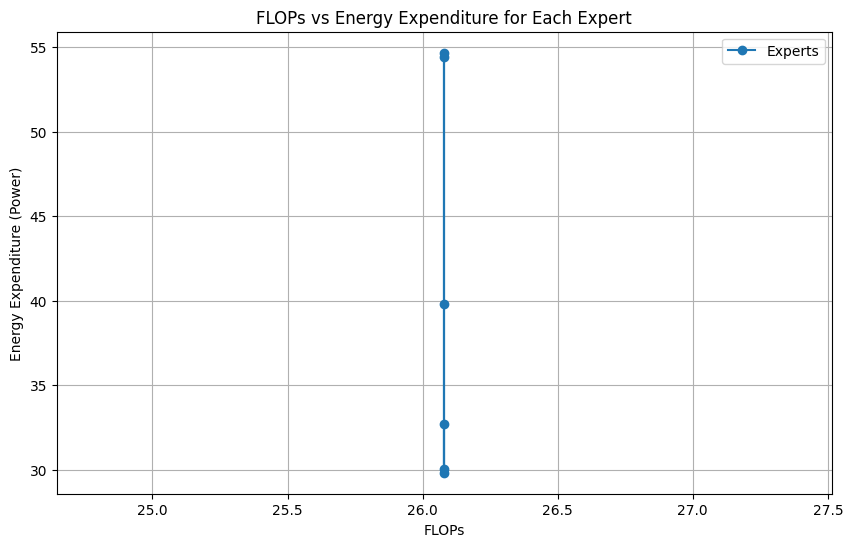

Computing calibration metrics...
Expected Calibration Error: 0.684


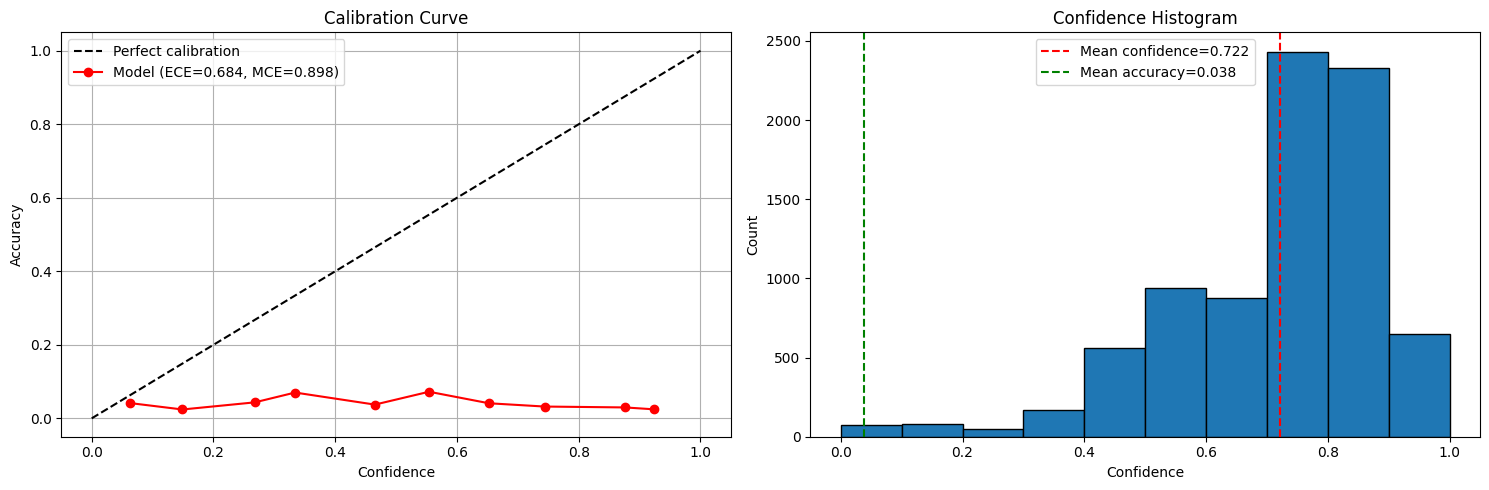

Energy for expert  0 51.355
Flops for expert layer  0 26.080182272
Energy for expert  1 46.5
Flops for expert layer  1 26.080182272
Energy for expert  2 46.35
Flops for expert layer  2 26.080182272
Energy for expert  3 47.37
Flops for expert layer  3 26.080182272
Energy for expert  4 50.1
Flops for expert layer  4 26.080182272
Energy for expert  5 37.75
Flops for expert layer  5 26.080182272


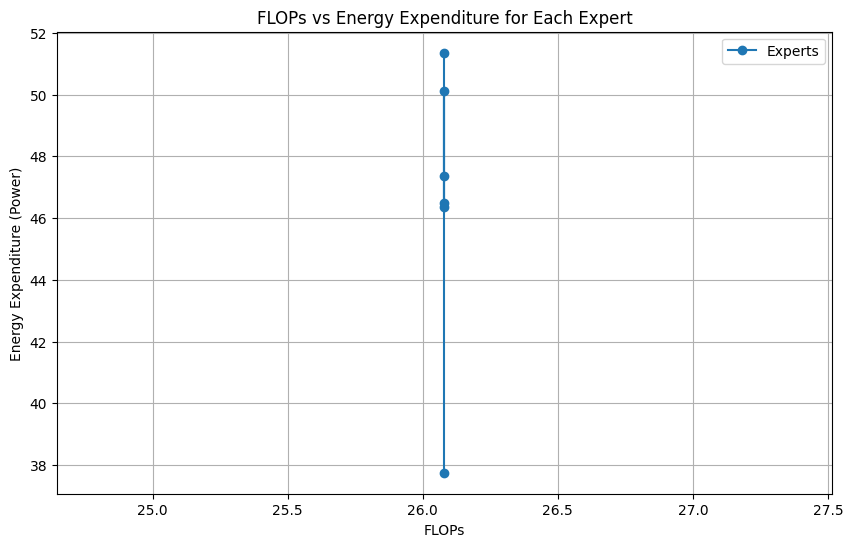

Energy for expert  0 53.66
Flops for expert layer  0 26.080182272
Energy for expert  1 48.2
Flops for expert layer  1 26.080182272
Energy for expert  2 72.65
Flops for expert layer  2 26.080182272
Energy for expert  3 59.145
Flops for expert layer  3 26.080182272
Energy for expert  4 30.02
Flops for expert layer  4 26.080182272
Energy for expert  5 51.81
Flops for expert layer  5 26.080182272


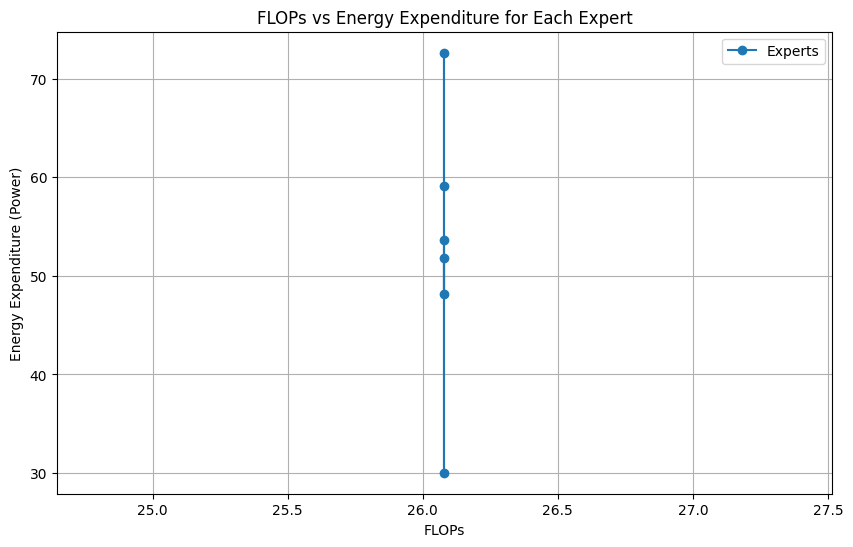

Epoch 2/5, Loss: 11.119543075561523, Top-k Accuracy (k=5): 0.1834558823529412


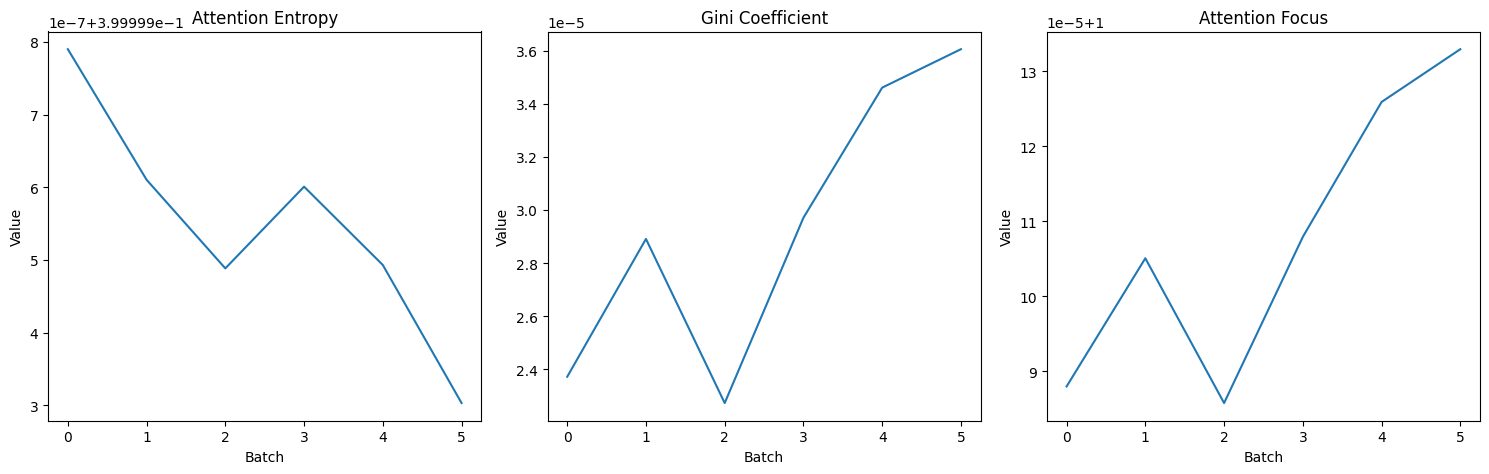


Computing calibration metrics...
Expected Calibration Error: 0.464


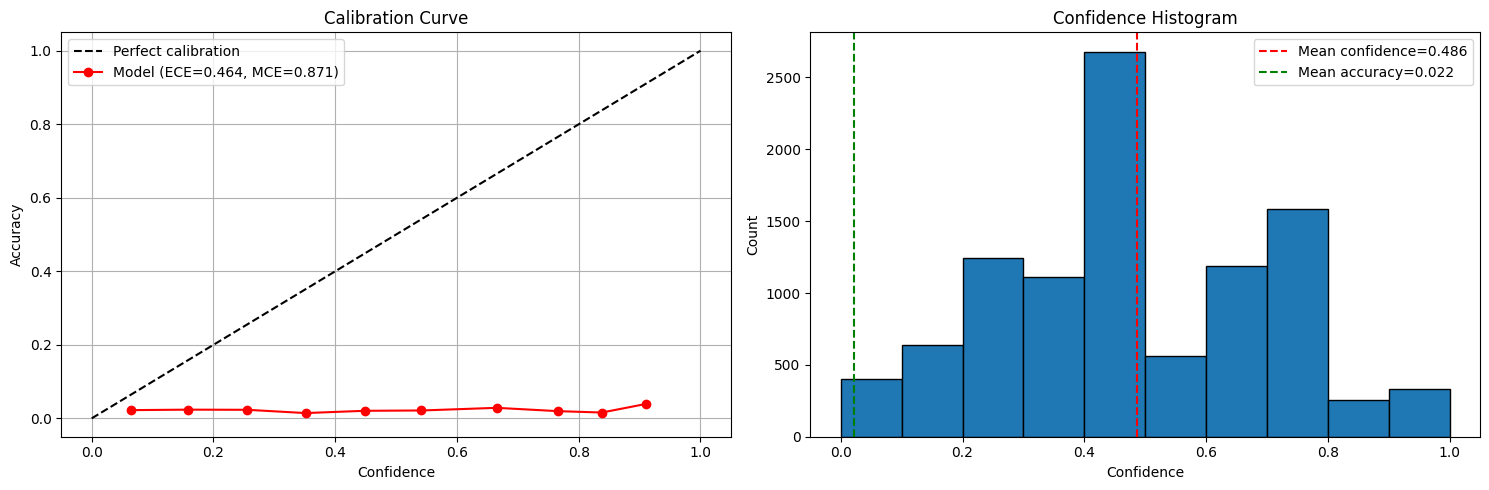

Energy for expert  0 49.595
Flops for expert layer  0 26.080182272
Energy for expert  1 30.2
Flops for expert layer  1 26.080182272
Energy for expert  2 53.15
Flops for expert layer  2 26.080182272
Energy for expert  3 34.62
Flops for expert layer  3 26.080182272
Energy for expert  4 30.12
Flops for expert layer  4 26.080182272
Energy for expert  5 55.67
Flops for expert layer  5 26.080182272


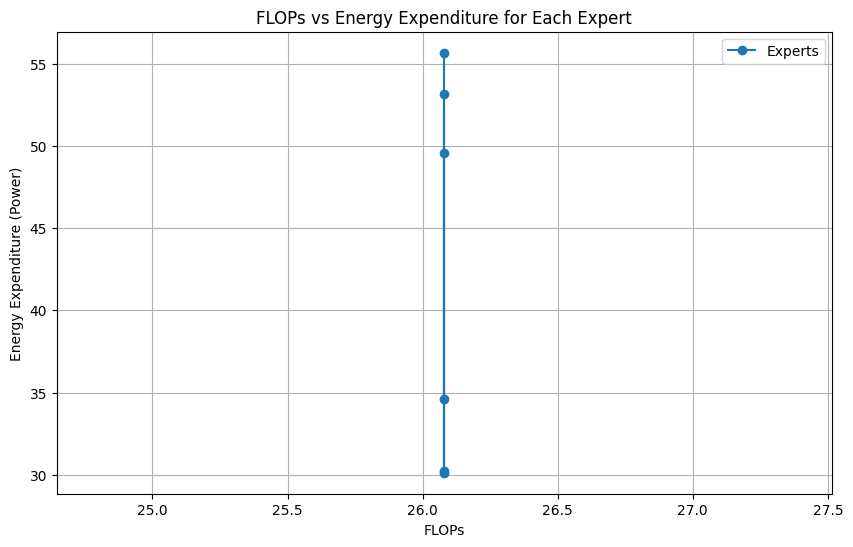

Computing calibration metrics...
Expected Calibration Error: 0.214


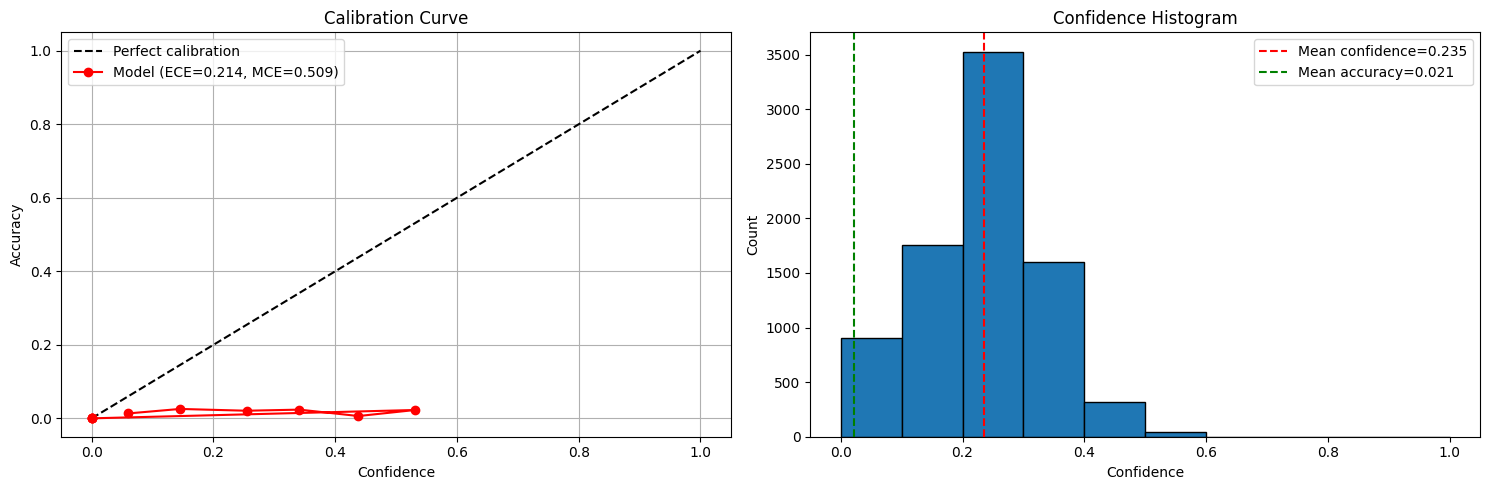

Energy for expert  0 63.97
Flops for expert layer  0 26.080182272
Energy for expert  1 71.22
Flops for expert layer  1 26.080182272
Energy for expert  2 30.3
Flops for expert layer  2 26.080182272
Energy for expert  3 44.31
Flops for expert layer  3 26.080182272
Energy for expert  4 41.58
Flops for expert layer  4 26.080182272
Energy for expert  5 54.92
Flops for expert layer  5 26.080182272


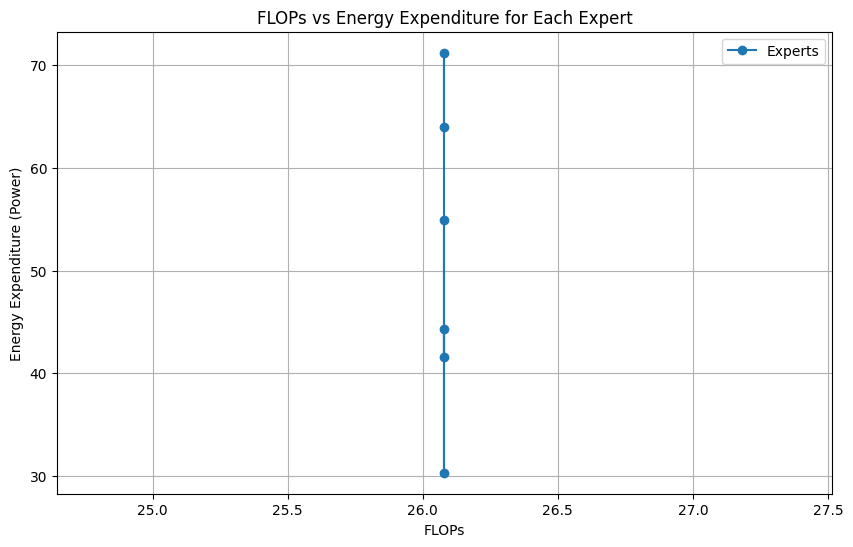

Energy for expert  0 40.57
Flops for expert layer  0 26.080182272
Energy for expert  1 59.64
Flops for expert layer  1 26.080182272
Energy for expert  2 36.145
Flops for expert layer  2 26.080182272
Energy for expert  3 37.08
Flops for expert layer  3 26.080182272
Energy for expert  4 35.305
Flops for expert layer  4 26.080182272
Energy for expert  5 39.65
Flops for expert layer  5 26.080182272


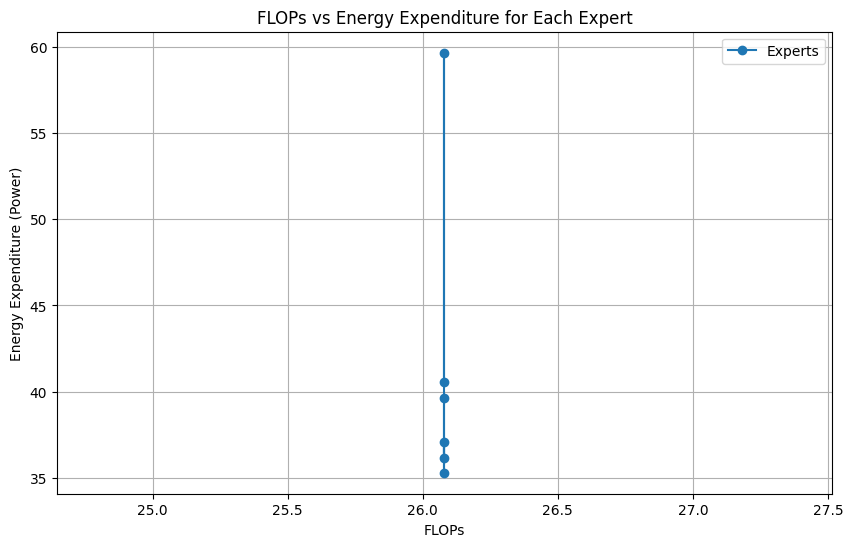

Epoch 3/5, Loss: 10.067469278971354, Top-k Accuracy (k=5): 0.09219771241830066


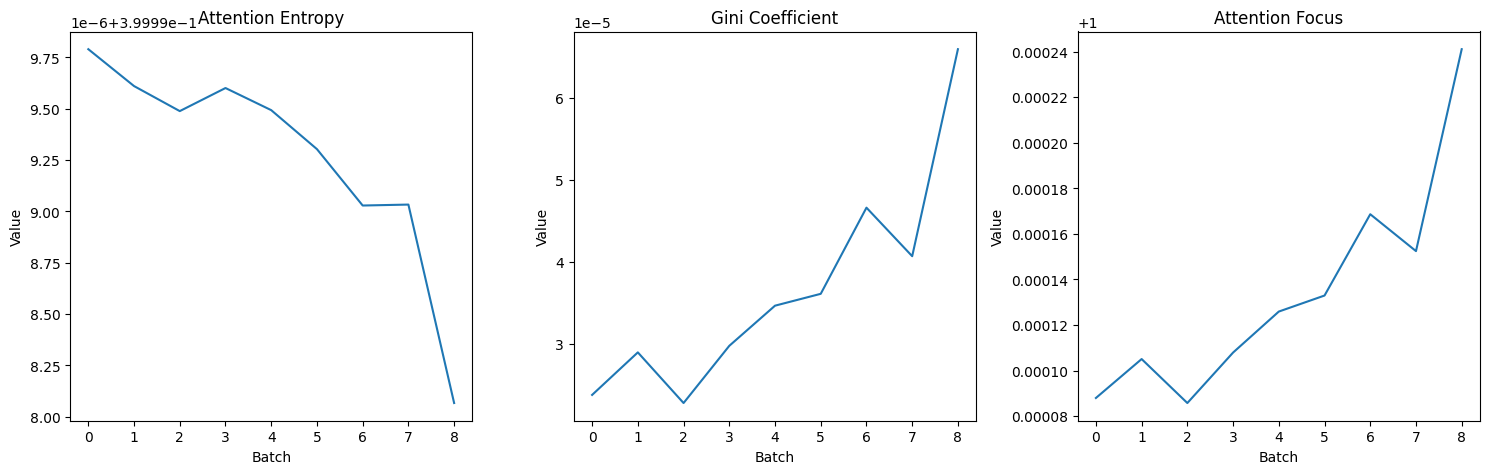


Computing calibration metrics...
Expected Calibration Error: 0.105


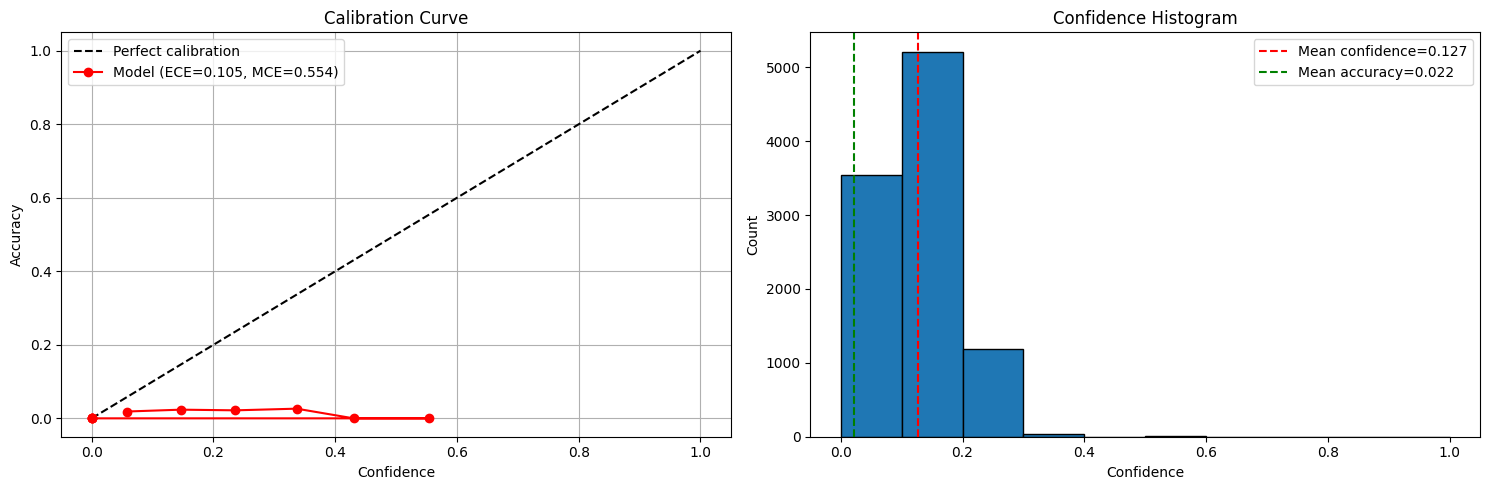

Energy for expert  0 69.16
Flops for expert layer  0 26.080182272
Energy for expert  1 40.135
Flops for expert layer  1 26.080182272
Energy for expert  2 46.55
Flops for expert layer  2 26.080182272
Energy for expert  3 60.26
Flops for expert layer  3 26.080182272
Energy for expert  4 30.0
Flops for expert layer  4 26.080182272
Energy for expert  5 29.71
Flops for expert layer  5 26.080182272


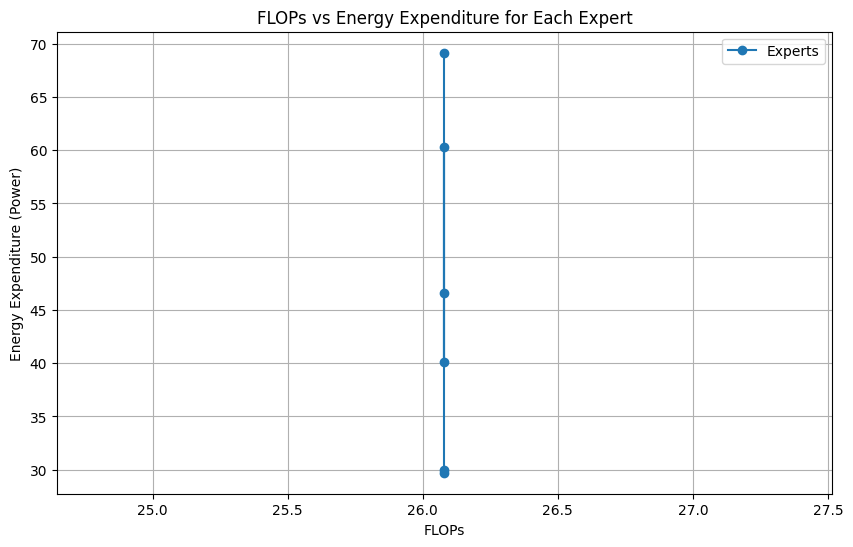

Computing calibration metrics...
Expected Calibration Error: 0.100


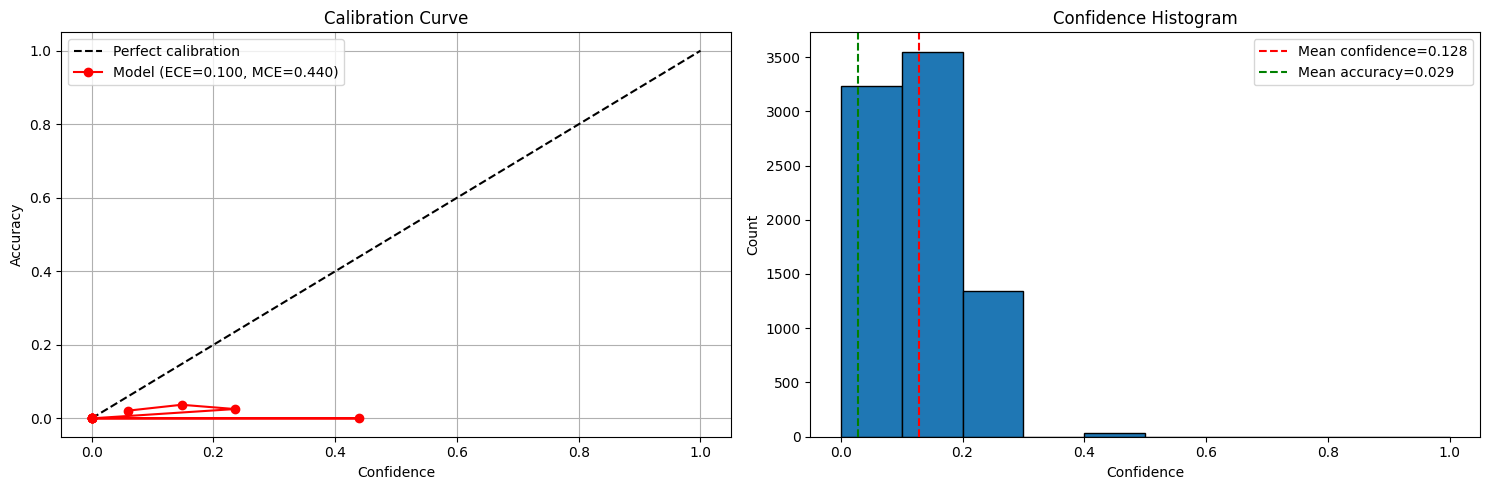

Energy for expert  0 53.05
Flops for expert layer  0 26.080182272
Energy for expert  1 36.59
Flops for expert layer  1 26.080182272
Energy for expert  2 61.59
Flops for expert layer  2 26.080182272
Energy for expert  3 48.625
Flops for expert layer  3 26.080182272
Energy for expert  4 52.07
Flops for expert layer  4 26.080182272
Energy for expert  5 33.629999999999995
Flops for expert layer  5 26.080182272


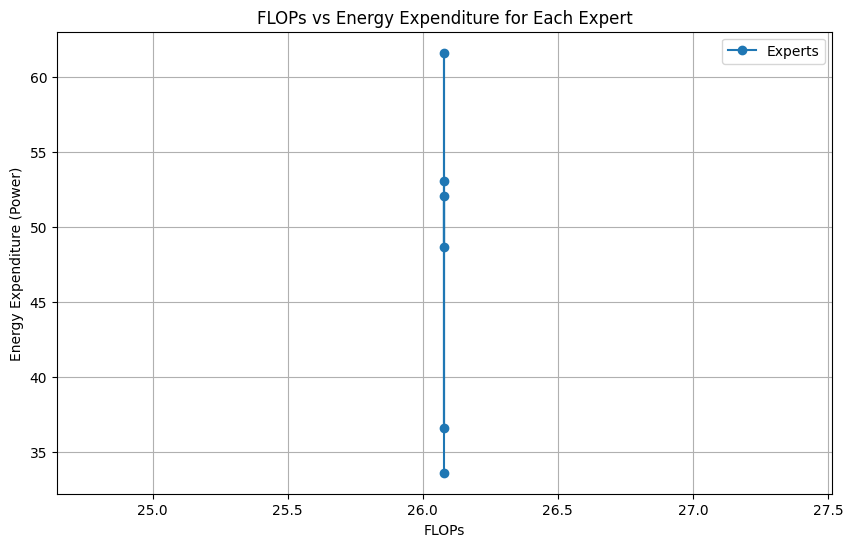

Energy for expert  0 57.6
Flops for expert layer  0 26.080182272
Energy for expert  1 61.53
Flops for expert layer  1 26.080182272
Energy for expert  2 53.35
Flops for expert layer  2 26.080182272
Energy for expert  3 43.13
Flops for expert layer  3 26.080182272
Energy for expert  4 30.0
Flops for expert layer  4 26.080182272
Energy for expert  5 33.975
Flops for expert layer  5 26.080182272


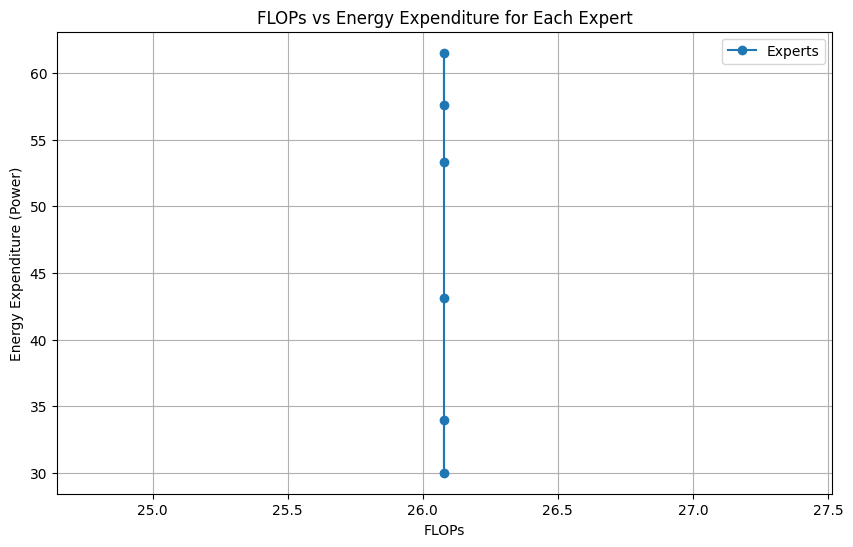

Epoch 4/5, Loss: 8.812463442484537, Top-k Accuracy (k=5): 0.14048202614379085


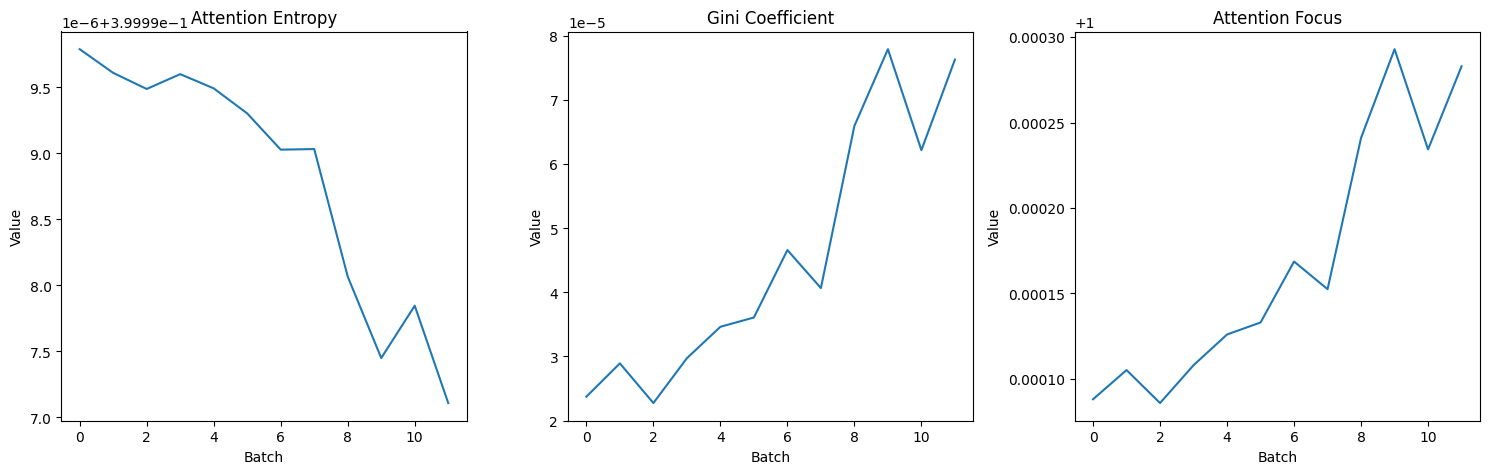


Computing calibration metrics...
Expected Calibration Error: 0.097


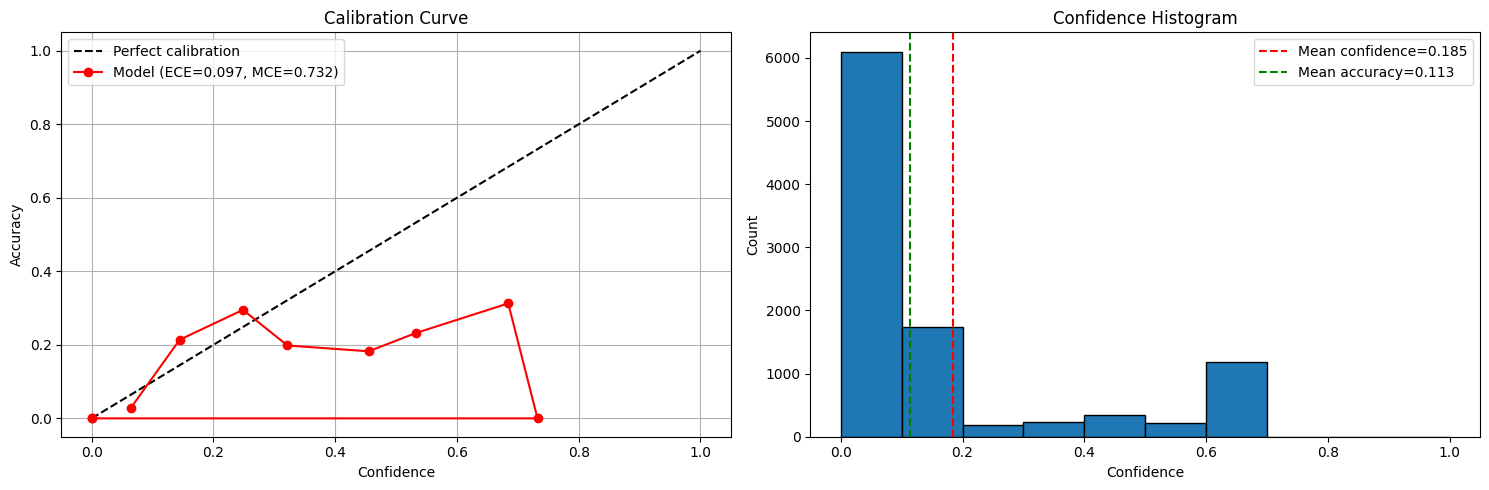

Energy for expert  0 46.375
Flops for expert layer  0 26.080182272
Energy for expert  1 39.215
Flops for expert layer  1 26.080182272
Energy for expert  2 30.6
Flops for expert layer  2 26.080182272
Energy for expert  3 53.15
Flops for expert layer  3 26.080182272
Energy for expert  4 34.915
Flops for expert layer  4 26.080182272
Energy for expert  5 42.93
Flops for expert layer  5 26.080182272


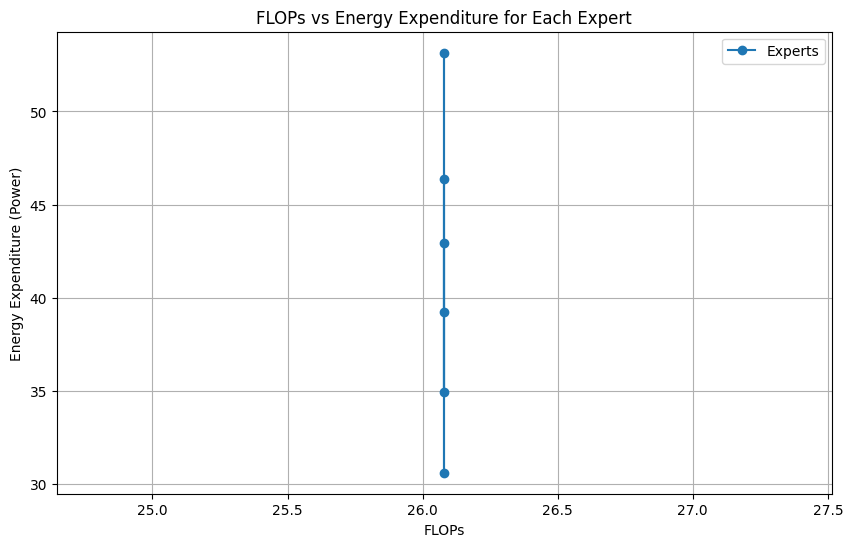

Computing calibration metrics...
Expected Calibration Error: 0.228


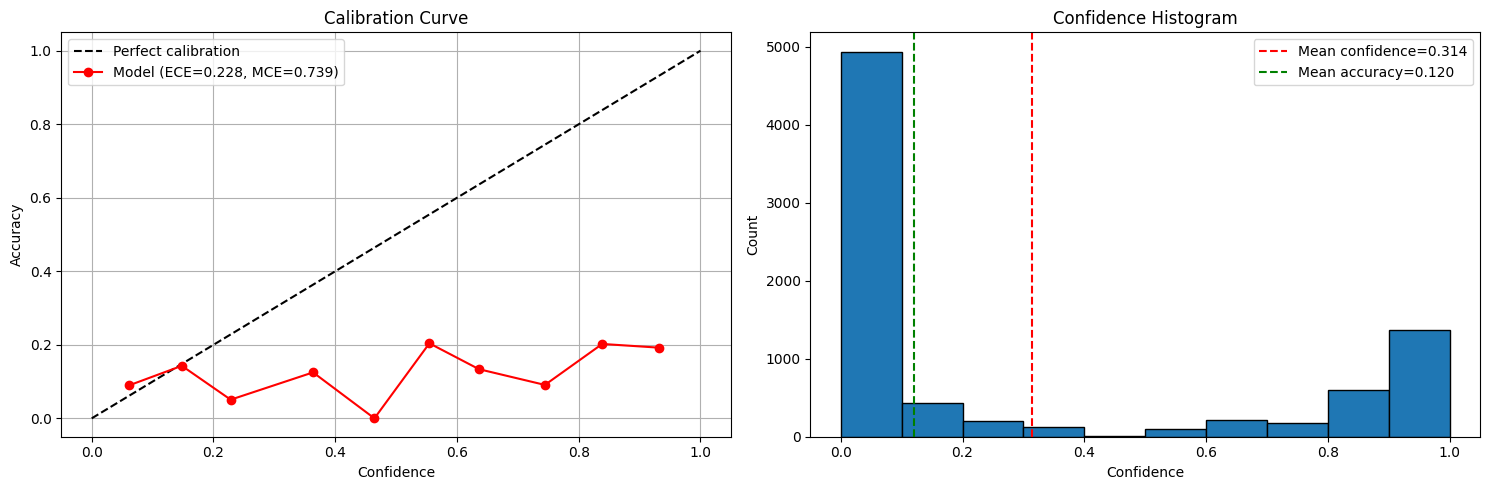

Energy for expert  0 50.345
Flops for expert layer  0 26.080182272
Energy for expert  1 38.12
Flops for expert layer  1 26.080182272
Energy for expert  2 71.62
Flops for expert layer  2 26.080182272
Energy for expert  3 54.82
Flops for expert layer  3 26.080182272
Energy for expert  4 30.0
Flops for expert layer  4 26.080182272
Energy for expert  5 32.665
Flops for expert layer  5 26.080182272


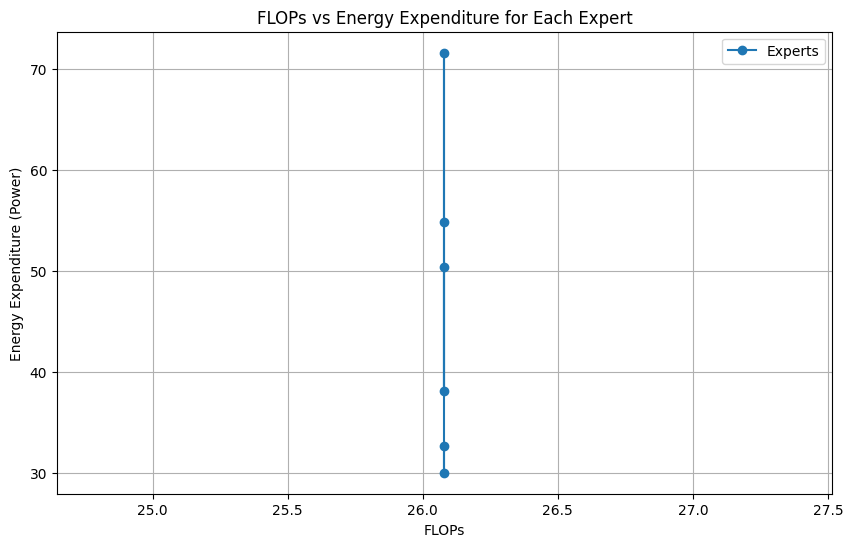

Energy for expert  0 61.57
Flops for expert layer  0 26.080182272
Energy for expert  1 57.84
Flops for expert layer  1 26.080182272
Energy for expert  2 52.92
Flops for expert layer  2 26.080182272
Energy for expert  3 35.72
Flops for expert layer  3 26.080182272
Energy for expert  4 29.53
Flops for expert layer  4 26.080182272
Energy for expert  5 56.37
Flops for expert layer  5 26.080182272


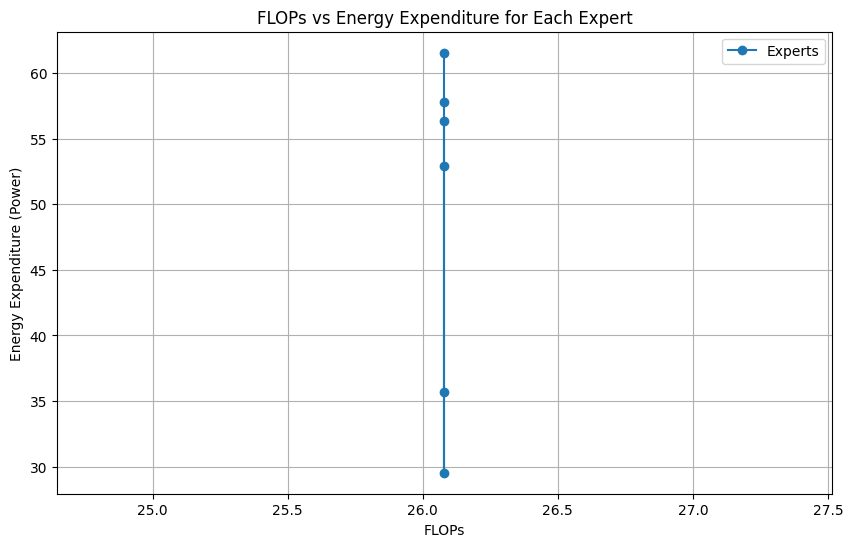

Epoch 5/5, Loss: 8.35549227396647, Top-k Accuracy (k=5): 0.2633986928104575


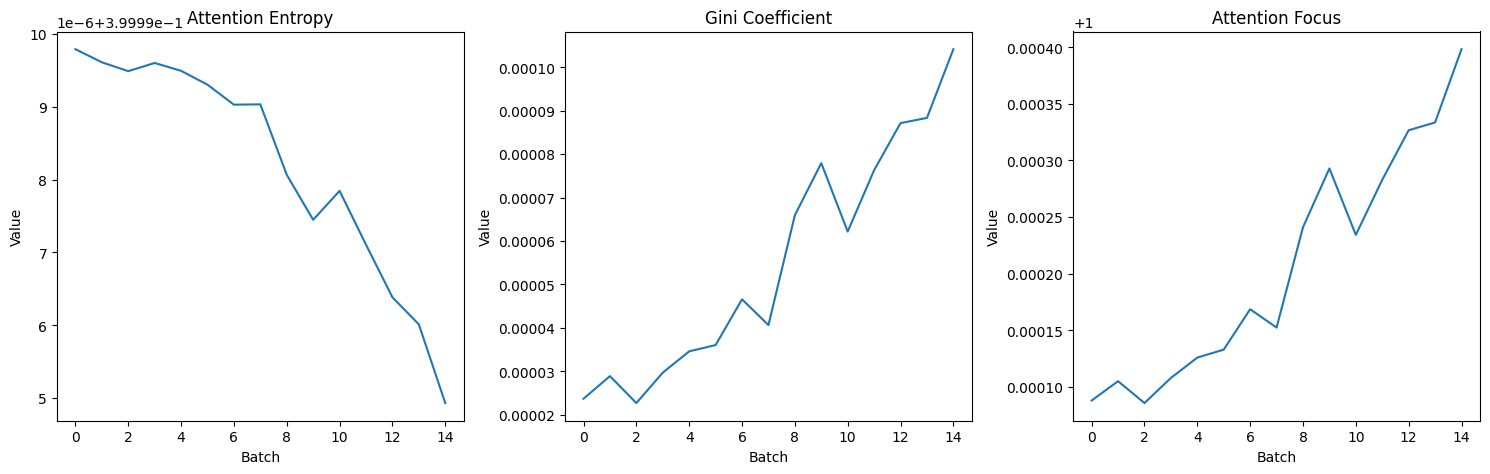


Computing calibration metrics...
Expected Calibration Error: 0.277


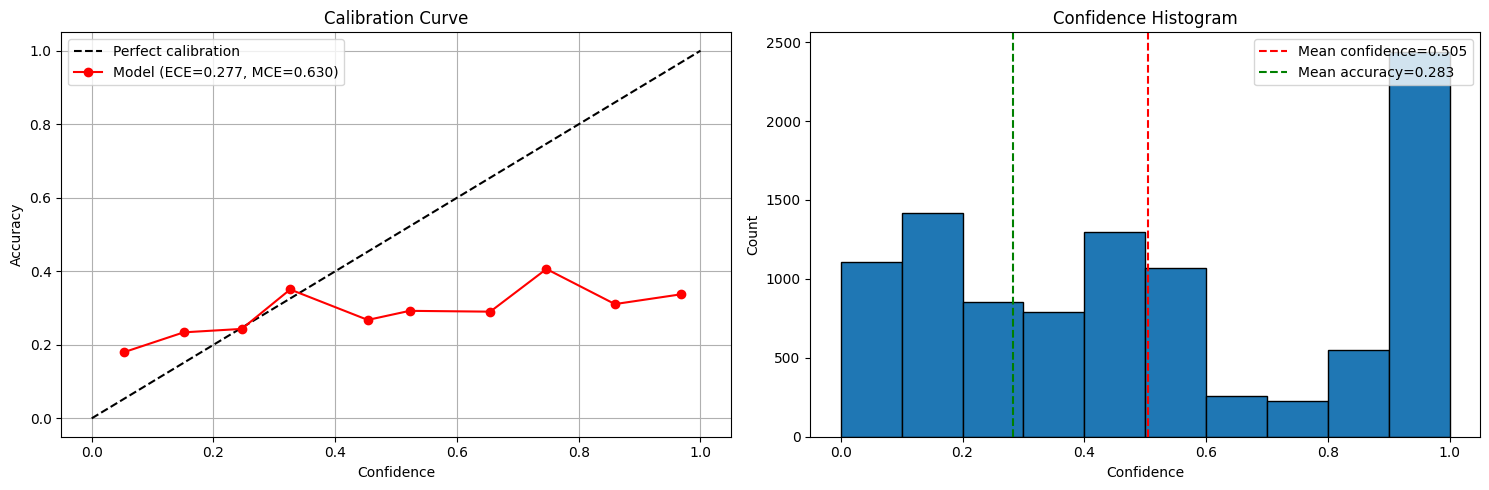

In [28]:
import torch
import torch.nn.functional as F
from torch import Tensor, nn
from zeta.nn import FeedForward, MultiQueryAttention
import torch.optim as optim
from torch.utils.data import DataLoader
import subprocess
import time
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from fvcore.nn import FlopCountAnalysis, flop_count
import numpy as np
from typing import Tuple, Optional
import random


# Top-k Accuracy metric: Measure how often correct token is within top-k predictions
def calculate_top_k_accuracy(logits, targets, k=5):
    with torch.no_grad():
        _, top_k_indices = logits.topk(k, dim=-1) # get top-k predictions
        targets_expanded = targets.unsqueeze(-1).expand_as(top_k_indices)
        correct = top_k_indices.eq(targets_expanded) # check if targets in top-k
        correct_total = correct.sum().item() # total correct predictions
        total = targets.numel() # total num targets
        accuracy = correct_total / total
    return accuracy


class DepthGate(nn.Module):
    def __init__(self, dim: int, max_depth: int):
        super().__init__()
        self.dim = dim
        self.max_depth = max_depth
        self.gate = nn.Linear(dim, max_depth)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        gate_scores = F.softmax(self.gate(x), dim=-1)
        return gate_scores

class TransformerLayer(nn.Module):
    def __init__(self, dim: int, num_heads: int, ff_hidden_dim: int):
        super().__init__()
        self.attention = nn.MultiheadAttention(dim, num_heads)
        self.feed_forward = nn.Sequential(
            nn.Linear(dim, ff_hidden_dim),
            nn.ReLU(),
            nn.Linear(ff_hidden_dim, dim)
        )
        self.norm1 = nn.LayerNorm(dim)
        self.norm2 = nn.LayerNorm(dim)
        self.last_attention_weights = None
        self.num_heads = num_heads

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # store attention weights during forward pass
        attn_output, attn_weights = self.attention(x, x, x)
        self.last_attention_weights = attn_weights
        x = self.norm1(x + attn_output)
        ff_output = self.feed_forward(x)
        x = self.norm2(x + ff_output)
        return x

    def get_attention_sparsity(self) -> Tuple[float, float, float]:
        """
        calculate attention sparsity metrics for last forward pass.
        returns:
            tuple containing (entropy, gini_coefficient, attention_focus)
        """
        if self.last_attention_weights is None:
            return 0.0, 0.0, 0.0

        # get attention weights and reshape to include head dimension
        attn = self.last_attention_weights.detach().cpu().numpy()
        batch_size, seq_len, _ = attn.shape
        # Reshape to (batch_size, num_heads, seq_len, seq_len)
        attn = attn.reshape(batch_size, seq_len, self.num_heads, -1)
        attn = np.transpose(attn, (0, 2, 1, 3))

        metrics = {
            'entropy': np.zeros((batch_size, self.num_heads)),
            'gini': np.zeros((batch_size, self.num_heads)),
            'focus': np.zeros((batch_size, self.num_heads))
        }

        epsilon = 1e-10  # small constant for numerical stability

        # calculate metrics per batch + head
        for b in range(batch_size):
            for h in range(self.num_heads):
                # get attention weights for this head
                head_attn = attn[b, h]

                # normalization
                head_attn = head_attn / (head_attn.sum(axis=-1, keepdims=True) + epsilon)

                # 1. entropy
                entropy = -np.sum(head_attn * np.log2(head_attn + epsilon), axis=-1)
                normalized_entropy = entropy / np.log2(seq_len)  # normalize to [0,1]
                metrics['entropy'][b, h] = np.mean(normalized_entropy)

                # 2. gini coefficient
                sorted_attn = np.sort(head_attn, axis=-1)  # Shape: [seq_len, seq_len]
                n = sorted_attn.shape[-1]
                index = np.arange(1, n + 1)
                # Calculate Gini for each row separately
                ginis = []
                for row in sorted_attn:
                    gini = ((2 * np.sum(index * row)) / (n * np.sum(row) + epsilon)) - ((n + 1) / n)
                    ginis.append(gini)
                metrics['gini'][b, h] = np.mean(ginis)

                # 3. attention focus
                max_attn = np.max(head_attn, axis=-1)
                mean_attn = np.mean(head_attn, axis=-1)
                focus = max_attn / (mean_attn + epsilon)
                metrics['focus'][b, h] = np.mean(focus)

        # avg across batches + heads
        final_metrics = (
            float(np.mean(metrics['entropy'])),
            float(np.mean(metrics['gini'])),
            float(np.mean(metrics['focus']))
        )

        return final_metrics

class MixtureOfDepthsTransformer(nn.Module):
    def __init__(self, num_tokens: int, dim: int, max_depth: int, num_heads: int, ff_hidden_dim: int, top_k: int):
        super().__init__()
        self.embedding = nn.Embedding(num_tokens, dim)
        self.max_depth = max_depth
        self.top_k = top_k
        self.depth_gate = DepthGate(dim, max_depth)
        self.layers = nn.ModuleList([TransformerLayer(dim, num_heads, ff_hidden_dim) for _ in range(max_depth)])
        self.fc_out = nn.Linear(dim, num_tokens)
        self.dim=dim
        self.flops_per_expert = []
        self.energy_per_expert = []

        # tracking for attention metrics
        self.attention_metrics_history = {
            'entropy': [],
            'gini': [],
            'focus': []
        }

    def get_layer_attention_metrics(self) -> dict:
        """
        Get attention metrics for all layers.
        Returns dictionary with per-layer metrics.
        """
        metrics = {'entropy': [], 'gini': [], 'focus': []}

        for i, layer in enumerate(self.layers):
            entropy, gini, focus = layer.get_attention_sparsity()
            metrics['entropy'].append(entropy)
            metrics['gini'].append(gini)
            metrics['focus'].append(focus)

        return metrics

    def update_attention_metrics_history(self, batch_metrics: dict):
        """Update running history of attention metrics"""
        for metric_name in ['entropy', 'gini', 'focus']:
            self.attention_metrics_history[metric_name].append(
                np.mean(batch_metrics[metric_name])
            )

    def plot_attention_metrics(self):
        """Plot the evolution of attention metrics over training"""
        plt.figure(figsize=(15, 5))

        # plot each metric
        metrics = ['entropy', 'gini', 'focus']
        titles = ['Attention Entropy', 'Gini Coefficient', 'Attention Focus']

        for i, (metric, title) in enumerate(zip(metrics, titles)):
            plt.subplot(1, 3, i+1)
            plt.plot(self.attention_metrics_history[metric])
            plt.title(title)
            plt.xlabel('Batch')
            plt.ylabel('Value')

        plt.tight_layout()
        plt.show()

    def compute_calibration_metrics(self, logits: torch.Tensor, targets: torch.Tensor, num_bins: int = 10) -> dict:
      calibration = CalibrationMetrics(num_bins=num_bins)
      calibration.update(logits, targets)
      metrics = calibration.compute_metrics()
      return metrics

    def add_noise_to_embeddings(embeddings, noise_factor=0.1):
      noise = torch.randn_like(embeddings) * noise_factor
      return embeddings + noise

    def get_gpu_power(self):
        # Use nvidia-smi to get the current power draw (in watts)
        try:
            power_info = subprocess.check_output(['nvidia-smi', '--query-gpu=power.draw', '--format=csv,noheader,nounits'])
            power_draw = float(power_info.strip())  # Power in watts (W)
            return power_draw
        except Exception as e:
            print("Error getting GPU power:", e)
            return 0

    def plot_flops_vs_energy(self):
        plt.figure(figsize=(10, 6))
        plt.plot(self.flops_per_expert, self.energy_per_expert, 'o-', label="Experts")
        plt.xlabel("FLOPs")
        plt.ylabel("Energy Expenditure (Power)")
        plt.title("FLOPs vs Energy Expenditure for Each Expert")
        plt.legend()
        plt.grid(True)
        plt.show()


    def forward(self, x: torch.Tensor) -> torch.Tensor:
        #print(x)
        # for i in range(x.size(0)):
        #      input_text = tokenizer.decode(inputs[i].tolist(), skip_special_tokens=True)
        #      print(f"Input Text: {input_text}")
        x = self.embedding(x)

        gate_scores = self.depth_gate(x)  # Shape: (batch_size, seq_len, max_depth)
        batch_size, seq_len, _ = x.size()

        # Initialize output tensor
        output = torch.zeros_like(x)
        # mask_total = torch.zeros(batch_size, seq_len, device=x.device)
        mask_total = torch.zeros(batch_size, seq_len, dtype=torch.bool, device=x.device)  # Use boolean mask
        all_tokens = x.clone()

        self.flops_per_expert.clear()
        self.energy_per_expert.clear()


        # Iterate through each depth (layer)
        for i in range(self.max_depth):
            # Get the top-K tokens for the current depth layer
            weights = gate_scores[:, :, i].unsqueeze(-1).expand(-1, -1, self.dim)
            weighted_scores = all_tokens*weights
            masked_scores = weighted_scores * (~mask_total).float().unsqueeze(-1)
            top_k_values, top_k_indices = masked_scores.topk(self.top_k, dim=-1, largest=True, sorted=False)  # Shape: (batch_size, seq_len, top_k)

            # Create a mask for top-K indices
            #mask = torch.zeros(batch_size, seq_len,  device=x.device)
            mask = torch.zeros(batch_size, seq_len, dtype=torch.bool, device=x.device)
            for b in range(batch_size):
                for s in range(seq_len):
                    mask[b, s] = torch.any(top_k_indices[b, s] == i)
            mask_total = mask_total | mask

            #mask = mask.unsqueeze(-1).expand(-1, -1, self.dim)
            masked_x = x * mask.unsqueeze(-1)
            #top_k_weights = gate_scores[:, :, i].unsqueeze(-1).expand(-1, -1, self.dim)
            #masked_x = x * mask
            weighted_x = masked_x * masked_scores
            initial_power = self.get_gpu_power()

            layer_output = self.layers[i](weighted_x)
            flops,_ = flop_count(self.layers[i],(weighted_x,))
            expert_flops = sum(flops.values())
            initial_power = self.get_gpu_power()
            layer_output = self.layers[i](weighted_x)
            final_power = self.get_gpu_power()
            avg_power = (initial_power + final_power) / 2
            print("Energy for expert ", i, avg_power)
            print("Flops for expert layer ", i, expert_flops)
            self.flops_per_expert.append(expert_flops)
            self.energy_per_expert.append(avg_power)
            output += layer_output
            #output = layer_output + x * (1 - mask)
            #x = output
            x = output * (~mask_total).unsqueeze(-1)
        self.plot_flops_vs_energy()
        return self.fc_out(output)

class CalibrationMetrics:
    def __init__(self, num_bins=10, pad_token_id=None, memory_size=10000):

        self.num_bins = num_bins
        self.pad_token_id = pad_token_id
        self.memory_size = memory_size
        self.confidences = []
        self.accuracies = []
        self.bins = np.linspace(0, 1, num_bins + 1)
        self.bin_lowers = self.bins[:-1]
        self.bin_uppers = self.bins[1:]

    def update(self, logits: torch.Tensor, targets: torch.Tensor):
        """
        update metrics with batch predictions

        """
        with torch.no_grad():
            # mask for valid tokens (non-padding)
            if self.pad_token_id is not None:
                valid_mask = targets != self.pad_token_id
            else:
                valid_mask = torch.ones_like(targets, dtype=torch.bool)

            # predicted probabilities and classes
            probs = torch.softmax(logits, dim=-1)
            pred_probs, pred_classes = probs.max(dim=-1)

            # Check prediction correctness
            correct = pred_classes.eq(targets)

            # apply valid mask
            masked_probs = pred_probs[valid_mask]
            masked_correct = correct[valid_mask]

            new_confidences = masked_probs.cpu().numpy()
            new_accuracies = masked_correct.float().cpu().numpy()

            if len(self.confidences) + len(new_confidences) > self.memory_size:    # maintain fixed memory size
                # remove oldest predictions to make room for new ones
                excess = len(self.confidences) + len(new_confidences) - self.memory_size
                self.confidences = self.confidences[excess:]
                self.accuracies = self.accuracies[excess:]

            self.confidences.extend(new_confidences)
            self.accuracies.extend(new_accuracies)

    def compute_metrics(self):
        """
        Compute calibration metrics including ECE, MCE, and bin statistics

        """
        confidences = np.array(self.confidences)
        accuracies = np.array(self.accuracies)

        bin_accuracies = np.zeros(self.num_bins)
        bin_confidences = np.zeros(self.num_bins)
        bin_counts = np.zeros(self.num_bins)
        max_calibration_error = 0.0

        # compute per-bin statistics
        for i in range(self.num_bins):
            mask = (confidences >= self.bin_lowers[i]) & (confidences < self.bin_uppers[i])
            bin_counts[i] = mask.sum()

            if bin_counts[i] > 0:
                bin_accuracies[i] = accuracies[mask].mean()
                bin_confidences[i] = confidences[mask].mean()

                # update max calibration error
                calibration_error = np.abs(bin_accuracies[i] - bin_confidences[i])
                max_calibration_error = max(max_calibration_error, calibration_error)

        # compute ECE
        ece = np.sum(np.abs(bin_accuracies - bin_confidences) * (bin_counts / len(confidences)))

        # compute additional reliability metrics
        mean_confidence = np.mean(confidences)
        mean_accuracy = np.mean(accuracies)
        overconfidence = mean_confidence - mean_accuracy

        return {
            'ece': float(ece),
            'mce': float(max_calibration_error),
            'overconfidence': float(overconfidence),
            'mean_confidence': float(mean_confidence),
            'mean_accuracy': float(mean_accuracy),
            'bin_accuracies': bin_accuracies,
            'bin_confidences': bin_confidences,
            'bin_counts': bin_counts
        }

    def plot_calibration(self):
        """plot calibration curve and confidence histogram"""
        metrics = self.compute_metrics()

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

        # calibration curve
        ax1.plot([0, 1], [0, 1], 'k--', label='Perfect calibration')
        ax1.plot(metrics['bin_confidences'],
                metrics['bin_accuracies'],
                'ro-',
                label=f'Model (ECE={metrics["ece"]:.3f}, MCE={metrics["mce"]:.3f})')
        ax1.set_xlabel('Confidence')
        ax1.set_ylabel('Accuracy')
        ax1.set_title('Calibration Curve')
        ax1.legend()
        ax1.grid(True)

        # confidence histogram
        ax2.hist(self.confidences, bins=self.bins, edgecolor='black')
        ax2.axvline(metrics['mean_confidence'],
                   color='r',
                   linestyle='--',
                   label=f'Mean confidence={metrics["mean_confidence"]:.3f}')
        ax2.axvline(metrics['mean_accuracy'],
                   color='g',
                   linestyle='--',
                   label=f'Mean accuracy={metrics["mean_accuracy"]:.3f}')
        ax2.set_xlabel('Confidence')
        ax2.set_ylabel('Count')
        ax2.set_title('Confidence Histogram')
        ax2.legend()

        plt.tight_layout()
        plt.show()

    def reset(self):
        """Reset stored predictions"""
        self.confidences = []
        self.accuracies = []

def perturb_input(input_ids, tokenizer, noise_type="substitution", dropout_prob=0.1, substitution_prob=0.3):
    """
    Perturbs the input tokenized text by applying dropout or substitution noise.

    input_ids: Tensor of shape (batch_size, seq_len)
    tokenizer: The tokenizer used to encode text.
    noise_type: Type of noise ('dropout' or 'substitution')
    dropout_prob: Probability of dropping tokens.
    substitution_prob: Probability of substituting tokens with random tokens.
    """
    batch_size, seq_len = input_ids.size()

    if noise_type == "dropout":
        # Word Dropout: Randomly set some token indices to the pad token
        for i in range(batch_size):
            for j in range(seq_len):
                if random.random() < dropout_prob:
                    input_ids[i, j] = tokenizer.pad_token_id

    elif noise_type == "substitution":
        # Word Substitution: Replace tokens with random tokens from the vocabulary
        vocab_size = tokenizer.vocab_size
        for i in range(batch_size):
            for j in range(seq_len):
                if random.random() < substitution_prob:
                    random_token = random.randint(0, vocab_size - 1)
                    input_ids[i, j] = random_token

    return input_ids

# Create DataLoader with custom collate_fn
def collate_fn(batch):
    input_ids = [item[0] for item in batch]
    max_length = 256
    padded_inputs = torch.stack([
        torch.cat([seq, torch.full((max_length - seq.size(0),), tokenizer.pad_token_id)])
        if seq.size(0) < max_length else seq[:max_length]
        for seq in input_ids
    ], dim=0)
    return {'input_ids': padded_inputs}

# Create DataLoader
dataloader = DataLoader(tokenized_data, batch_size=32, shuffle=True, drop_last=True,collate_fn=collate_fn)


num_tokens = tokenizer.vocab_size
model = MixtureOfDepthsTransformer(num_tokens=num_tokens, dim=512, max_depth=6, num_heads=8, ff_hidden_dim=2048,top_k=5)


# Loss, optimizer, and training loop
criterion = torch.nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-4)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=1000, gamma=0.9)

num_epochs = 5
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

total_top_k_accuracy = 0
num_batches = 0
calibration_tracker = CalibrationMetrics(num_bins=10)
k = 5

# TRAINING LOOP
for epoch in range(num_epochs):
    model.train()
    total_loss = 0

    # reset at start of each epoch
    total_top_k_accuracy = 0
    num_batches = 0

    for batch in dataloader:
        inputs = batch['input_ids'].to(device)
        #inputs = perturb_input(inputs.clone(), tokenizer, noise_type="substitution", substitution_prob=0.1)
        #print(inputs.shape)

        # Forward pass
        optimizer.zero_grad()
        outputs = model(inputs)

        # The model's output is (batch_size, seq_length, num_tokens)
        # We need to shift targets for next-token prediction (e.g., language modeling)
        logits = outputs[:, :-1, :].contiguous()
        targets = inputs[:, 1:].contiguous()

        loss = criterion(logits.view(-1, num_tokens), targets.view(-1))

        # calibration tracking
        calibration_tracker.update(logits, targets)

        # every N batches or at epoch end, compute and plot calibration
        if num_batches % 100 == 0:  # adjust frequency as needed
            print("Computing calibration metrics...")
            metrics = calibration_tracker.compute_metrics()
            print(f"Expected Calibration Error: {metrics['ece']:.3f}")
            calibration_tracker.plot_calibration()

        # Get and store attention metrics
        attention_metrics = model.get_layer_attention_metrics()
        model.update_attention_metrics_history(attention_metrics)

        # Top-k accuracy calculation
        top_k_accuracy = calculate_top_k_accuracy(logits, targets, k=k)
        total_top_k_accuracy += top_k_accuracy
        num_batches += 1

        # Backpropagation and optimization
        loss.backward()
        optimizer.step()

        # Update total loss
        total_loss += loss.item()

        # for i in range(inputs.size(0)):
        #     input_text = tokenizer.decode(inputs[i].tolist(), skip_special_tokens=True)
        #     #print(f"Input Text: {input_text}")

        #     # Extract the most likely token indices for the output
        #     top_token_indices = outputs[i].argmax(dim=-1)  # Shape: [seq_length]
        #     output_text = tokenizer.decode(top_token_indices.tolist(), skip_special_tokens=True)
        #     #print(f"Output Text: {output_text}")

    # at end of each epoch
    print(f"Epoch {epoch + 1}/{num_epochs}, Loss: {total_loss/len(dataloader)}, Top-k Accuracy (k={k}): {total_top_k_accuracy / num_batches}")

    model.plot_attention_metrics()

    print("\nComputing calibration metrics...")
    metrics = calibration_tracker.compute_metrics()
    print(f"Expected Calibration Error: {metrics['ece']:.3f}")
    calibration_tracker.plot_calibration()
    calibration_tracker.reset()


    # Step the learning rate scheduler, if any
    scheduler.step()